In [11]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands
import pandas as pd
import numpy as np
import pickle
train_info = GraphsTraining()

### Load Pyomo results in

In [11]:
results_pyomo = load_all_pickles("results/pyomo_rl_2026-01-07_23-36-45", recursive=False)[0]
df_reg = Results.collect_data(results_pyomo)
reg = Results.columns_to_lists(df_reg)
reg.keys()

Loaded results/pyomo_rl_2026-01-07_23-36-45/results_full.pkl

Loaded 1 files from results/pyomo_rl_2026-01-07_23-36-45


dict_keys(['Times_Elapsed', 'MSE_odeint', 'MSE_collocation', 'MSE_odeint_test', 'MSE_collocation_test'])

### Load JAX results in

In [16]:
fn = "results/jax_rl_runs/jax_rl_2026-01-08_22-17-41/results_NO_logging.pkl"
with open(fn, 'rb') as file:
    results_jax_no_log = pickle.load(file)
    
fn = "results/jax_rl_runs/jax_rl_2026-01-08_22-17-41/results_WITH_logging.pkl"
with open(fn, 'rb') as file:
    results_jax_with_log = pickle.load(file)
    

### Load PyTorch results in

In [ ]:
fn = "results/pytorch_rl_runs/jax_rl_2026-01-08_22-17-41/results_NO_logging.pkl"
with open(fn, 'rb') as file:
    pytorch_jax_no_log = pickle.load(file)
    
fn = "results/pytorch_rl_runs/jax_rl_2026-01-08_22-17-41/results_WITH_logging.pkl"
with open(fn, 'rb') as file:
    pytorch_jax_with_log = pickle.load(file)
    

In [18]:
results_jax_no_log

{(1, '2015-01-15'): {'times_elapsed': 4.229607105255127,
  'mse_diffrax': 1.4933159809440832,
  'mse_diffrax_test': 4.6482671903135016},
 (1, '2015-01-18'): {'times_elapsed': 8.24978256225586,
  'mse_diffrax': 0.9906046364565063,
  'mse_diffrax_test': 2.1849886533653846},
 (1, '2015-01-21'): {'times_elapsed': 4.17601752281189,
  'mse_diffrax': 1.4152835081839372,
  'mse_diffrax_test': 2.380154388820719},
 (1, '2015-01-24'): {'times_elapsed': 4.167589902877808,
  'mse_diffrax': 1.0323979725866046,
  'mse_diffrax_test': 3.5780896275289518},
 (1, '2015-01-27'): {'times_elapsed': 4.305634498596191,
  'mse_diffrax': 1.542015200259147,
  'mse_diffrax_test': 1.4945705008845216},
 (1, '2015-01-30'): {'times_elapsed': 4.137749195098877,
  'mse_diffrax': 1.1495405813701973,
  'mse_diffrax_test': 2.547283019808894},
 (1, '2015-02-02'): {'times_elapsed': 4.135412931442261,
  'mse_diffrax': 1.582849494674473,
  'mse_diffrax_test': 1.6911276933556258},
 (1, '2015-02-05'): {'times_elapsed': 8.7583525

In [24]:
results_jax_with_log["training_losses"][1]

[([2.1612424870778635,
   1.9838899245141233,
   1.779392287141809,
   1.6158937180290727,
   1.5315377107666555,
   1.3734342251747933,
   1.3300981272313444,
   1.1377221708161422,
   1.1125406076869586,
   1.0664311154877903,
   0.9906046364565063],
  [2.563019012077762,
   2.501092493269626,
   2.458319353370433,
   2.418230579640196,
   2.376036439617334,
   2.336671214485077,
   2.2910128141423907,
   2.2555846010998146,
   2.231719698697347,
   2.220075602227192,
   2.1849886533653846])]

In [55]:
fn = "results/pyomo_rl_2026-01-07_23-36-45/results_full.pkl"
#fn = 'results/convergence_2024-09-02_17-22-56_full.pkl'
pyomo_convergence = Results.load_results(fn)

keys = {k:k for k in list(pyomo_convergence.values())[0].keys()}
pyomo_df = Results.collect_data(pyomo_convergence, keys)

df = pyomo_df.drop(columns=['result']).reset_index(drop=True)
list_cols = df.columns.tolist()

N_SEEDS = 10  # <-- set this

def seed_labels_chunked(xs, n_seeds):
    L = len(xs)
    n_steps = L // n_seeds
    return list(np.repeat(np.arange(n_seeds), n_steps))

def step_labels_chunked(xs, n_seeds):
    L = len(xs)
    n_steps = L // n_seeds
    return list(np.tile(np.arange(n_steps), n_seeds))

df['seed'] = df[list_cols[0]].apply(lambda xs: seed_labels_chunked(xs, N_SEEDS))

pyomo_long = df.explode(list_cols + ['seed'], ignore_index=True).rename(columns = {"times_elapsed":"time_elapsed"})


In [57]:
comparison_dfs = {
    "Pyomo": pyomo_long
}

In [66]:
pyomo_long.head(1)

,time_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test,seed
0,0.258741,0.430548,0.43789,12.802369,12.44861,0


/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:702: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


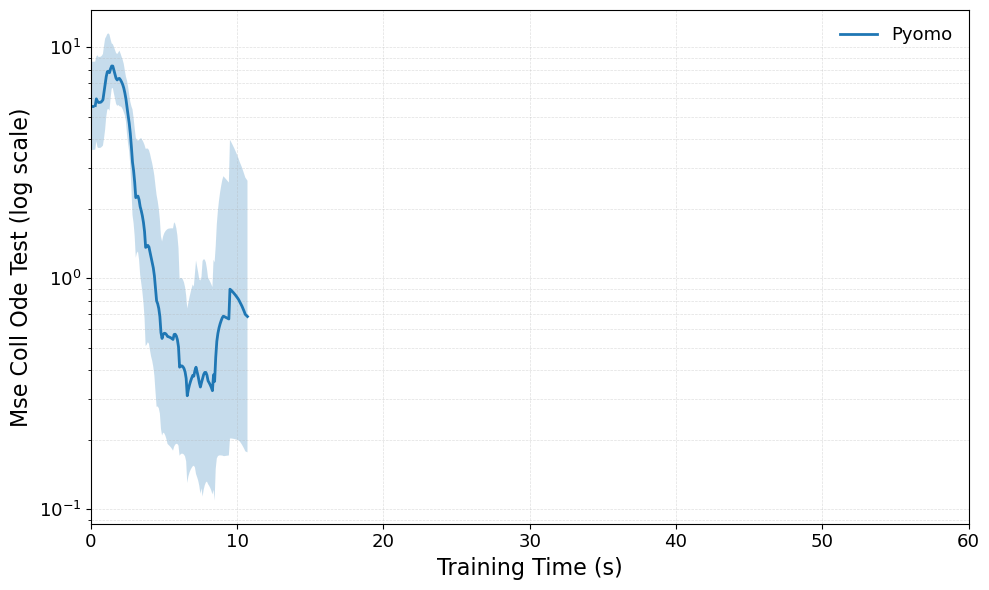

<Axes: xlabel='Training Time (s)', ylabel='Mse Coll Ode Test (log scale)'>

In [ ]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_coll_ode_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 60)
)

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:702: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


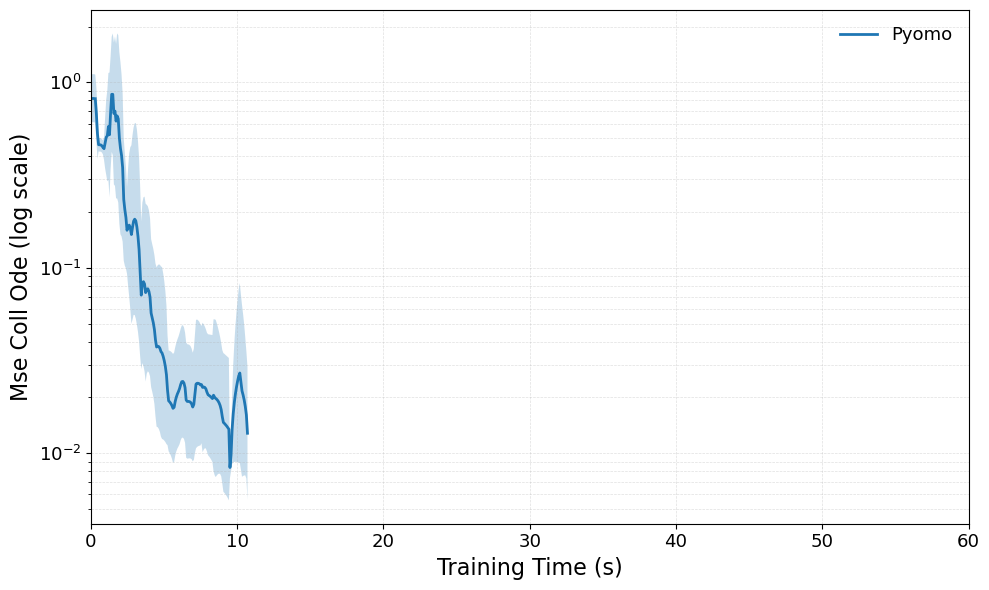

<Axes: xlabel='Training Time (s)', ylabel='Mse Coll Ode (log scale)'>

In [ ]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_coll_ode",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 60)
)

In [34]:
pyomo_df

,result,time_elapsed,mse_odeint,training_loss,mse_odeint_test,mse_coll_ode_test,times
i,,,,,,,
1,"[{'solver_time': 0.2587406635284424, 'terminat...",11.815327,"[0.4305479280807117, 0.4305479280807117, 0.430...","[0.4378899743762439, 0.4378899743762439, 0.437...","[12.802369409113153, 12.802369409113153, 12.80...","[12.44860960672505, 12.44860960672505, 12.4486...","[0.0, 0.23630653381347655, 0.4726130676269531,..."


In [43]:
list(pyomo_df["times"])

[array([ 0.        ,  0.23630653,  0.47261307,  0.7089196 ,  0.94522614,
         1.18153267,  1.4178392 ,  1.65414574,  1.89045227,  2.1267588 ,
         2.36306534,  2.59937187,  2.83567841,  3.07198494,  3.30829147,
         3.54459801,  3.78090454,  4.01721107,  4.25351761,  4.48982414,
         4.72613068,  4.96243721,  5.19874374,  5.43505028,  5.67135681,
         5.90766335,  6.14396988,  6.38027641,  6.61658295,  6.85288948,
         7.08919601,  7.32550255,  7.56180908,  7.79811562,  8.03442215,
         8.27072868,  8.50703522,  8.74334175,  8.97964828,  9.21595482,
         9.45226135,  9.68856789,  9.92487442, 10.16118095, 10.39748749,
        10.63379402, 10.87010056, 11.10640709, 11.34271362, 11.57902016])]